# Hybrid SNR-aware Attention

This notebook evaluates an inference-time hybrid of two trained models:

- use plain differential attention for low/transition SNR: `-8 dB` to `+2 dB`
- use normal attention outside that range

The goal is to test the research claim:

> Differential attention is useful mainly in low SNR, while normal attention remains stronger at cleaner SNR.

The final result is compared against the normal attention baseline and exported under:

```text
experiments/5class_hybrid_snr_aware_attention/
```


In [1]:
# CELL 1: Setup repo and paths
import os
import sys
import shutil
import subprocess
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, FileLink

os.environ["KERAS_BACKEND"] = "tensorflow"

REPO_URL = "https://github.com/akshlabh/amr-5-class.git"
WORK_DIR = Path("/kaggle/working/amr-5-class")
DATASET = Path("/kaggle/input/datasets/gustavopolicarpo/rml201610a-dict/RML2016.10a_dict.dat")


def find_attached_repo():
    for root in Path("/kaggle/input").glob("**"):
        if (root / "src" / "train.py").exists() and (root / "configs").exists():
            return root
    return None


if (WORK_DIR / ".git").exists():
    subprocess.run(["git", "-C", str(WORK_DIR), "pull"], check=False)
elif WORK_DIR.exists() and (WORK_DIR / "src" / "train.py").exists():
    print(f"Using existing work dir: {WORK_DIR}")
else:
    attached = find_attached_repo()
    if attached is not None:
        print(f"Copying attached repo from: {attached}")
        if WORK_DIR.exists():
            shutil.rmtree(WORK_DIR)
        shutil.copytree(attached, WORK_DIR)
    else:
        print("Cloning repo from GitHub...")
        subprocess.run(["git", "clone", REPO_URL, str(WORK_DIR)], check=True)

os.chdir(WORK_DIR)
if str(WORK_DIR) not in sys.path:
    sys.path.insert(0, str(WORK_DIR))

NORMAL_DIR = Path("experiments/5class_attention")
DIFF_DIR = Path("experiments/5class_diffattention")
HYBRID_DIR = Path("experiments/5class_hybrid_snr_aware_attention")

required = [
    "src/evaluate_hybrid_snr_aware_attention.py",
    "src/models/mcldnn_attention.py",
    "src/models/mcldnn_diffattention.py",
    "configs/exp_5class_attention.yaml",
    "configs/exp_5class_diffattention.yaml",
    "src/train.py",
]

print(f"Working dir: {Path.cwd()}")
print(f"Dataset    : {DATASET}")
print(f"Dataset OK : {DATASET.exists()}")
for f in required:
    print(f"{'OK' if Path(f).exists() else 'MISSING'} {f}")

assert DATASET.exists(), f"Dataset not found: {DATASET}"
for f in required:
    assert Path(f).exists(), f"Required repo file missing: {f}"


Cloning repo from GitHub...


Cloning into '/kaggle/working/amr-5-class'...


Working dir: /kaggle/working/amr-5-class
Dataset    : /kaggle/input/datasets/gustavopolicarpo/rml201610a-dict/RML2016.10a_dict.dat
Dataset OK : True
OK src/evaluate_hybrid_snr_aware_attention.py
OK src/models/mcldnn_attention.py
OK src/models/mcldnn_diffattention.py
OK configs/exp_5class_attention.yaml
OK configs/exp_5class_diffattention.yaml
OK src/train.py


In [2]:
# CELL 2: Ensure normal and plain differential attention checkpoints exist
# These are the two source models used by the hybrid.

baseline_jobs = [
    ("normal_attention", NORMAL_DIR, "configs/exp_5class_attention.yaml"),
    ("plain_diffattention", DIFF_DIR, "configs/exp_5class_diffattention.yaml"),
]

for name, exp_dir, cfg in baseline_jobs:
    weights = exp_dir / "checkpoints" / "best_model.weights.h5"
    score = exp_dir / "results" / "test_score.csv"
    snr = exp_dir / "results" / "acc_per_snr.csv"
    if weights.exists() and score.exists() and snr.exists():
        print(f"{name}: existing checkpoint/results found.")
    else:
        print(f"{name}: missing checkpoint/results. Training now...")
        subprocess.run([
            sys.executable, "src/train.py",
            "--config", cfg,
            "--datasetpath", str(DATASET),
        ], check=True)
    print(f"  weights={weights.exists()}  score={score.exists()}  snr={snr.exists()}")


normal_attention: existing checkpoint/results found.
  weights=True  score=True  snr=True
plain_diffattention: existing checkpoint/results found.
  weights=True  score=True  snr=True


In [3]:
# CELL 3: Evaluate Hybrid SNR-aware Attention
# Default rule: use differential attention for -8 <= SNR <= +2, normal elsewhere.

if HYBRID_DIR.exists():
    print(f"Removing old hybrid outputs: {HYBRID_DIR}")
    shutil.rmtree(HYBRID_DIR)

process = subprocess.Popen(
    [
        sys.executable, "-u", "src/evaluate_hybrid_snr_aware_attention.py",
        "--datasetpath", str(DATASET),
        "--normal-weights", str(NORMAL_DIR / "checkpoints" / "best_model.weights.h5"),
        "--diff-weights", str(DIFF_DIR / "checkpoints" / "best_model.weights.h5"),
        "--output-dir", str(HYBRID_DIR),
        "--diff-snr-min", "-8",
        "--diff-snr-max", "2",
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)

for line in process.stdout:
    print(line, end="", flush=True)

return_code = process.wait()
if return_code != 0:
    raise subprocess.CalledProcessError(return_code, process.args)

print("Hybrid evaluation finished.")
print("Results:", (HYBRID_DIR / "results" / "test_score.csv").exists())
print("SNR CSV:", (HYBRID_DIR / "results" / "acc_per_snr.csv").exists())



  Experiment : 5class_hybrid_snr_aware_attention
  Rule       : SNR-aware normal/diff attention selection
  Mode       : validation_best
  Low SNR    : SNR <= 2 dB
  Val margin : diff must beat normal by > 0.0000
  Normal ckpt: experiments/5class_attention/checkpoints/best_model.weights.h5
  Diff ckpt  : experiments/5class_diffattention/checkpoints/best_model.weights.h5
  Output dir : experiments/5class_hybrid_snr_aware_attention

[dataset] Loading 5 classes: ['BPSK', 'QPSK', '8PSK', 'QAM16', 'QAM64']
[dataset] SNR range: -20 dB to 18 dB  (20 levels)
[dataset] After normalization — train RMS: 1.0000  (should be ≈1.0)
[dataset] Split: 60000 train | 20000 val | 20000 test samples
I0000 00:00:1782978165.506743     119 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: Use

In [4]:
# CELL 4: Display key comparison tables and plots
score = pd.read_csv(HYBRID_DIR / "results" / "test_score.csv")
snr = pd.read_csv(HYBRID_DIR / "results" / "acc_per_snr.csv")

print("Test score summary:")
display(score)

print("Per-SNR hybrid vs normal:")
display(snr)

fig_path = HYBRID_DIR / "figures" / "hybrid_vs_normal_acc_vs_snr.png"
delta_path = HYBRID_DIR / "figures" / "hybrid_minus_normal_delta_by_snr.png"
print("Saved plots:")
print(fig_path)
print(delta_path)


Test score summary:


,model,loss,accuracy
0,normal_attention,0.917688,0.61235
1,hybrid_snr_aware_attention,0.976715,0.62350


Per-SNR hybrid vs normal:


,snr,normal_attention_accuracy,hybrid_accuracy,delta_hybrid_minus_normal,selected_model,normal_val_accuracy,diff_val_accuracy,diff_minus_normal_val
0,-20,0.329,0.324,-0.005,diff_attention,0.307,0.336,0.029
1,-18,0.309,0.360,0.051,diff_attention,0.295,0.336,0.041
2,-16,0.320,0.325,0.005,diff_attention,0.292,0.327,0.035
3,-14,0.317,0.339,0.022,diff_attention,0.306,0.331,0.025
4,-12,0.303,0.331,0.028,diff_attention,0.314,0.336,0.022
5,-10,0.276,0.304,0.028,diff_attention,0.272,0.326,0.054
6,-8,0.283,0.321,0.038,diff_attention,0.298,0.303,0.005
7,-6,0.324,0.320,-0.004,diff_attention,0.300,0.327,0.027
8,-4,0.400,0.411,0.011,diff_attention,0.407,0.440,0.033
9,-2,0.572,0.621,0.049,diff_attention,0.562,0.589,0.027


Saved plots:
experiments/5class_hybrid_snr_aware_attention/figures/hybrid_vs_normal_acc_vs_snr.png
experiments/5class_hybrid_snr_aware_attention/figures/hybrid_minus_normal_delta_by_snr.png


Normal vs Hybrid headline summary:


,comparison,normal_accuracy_percent,hybrid_accuracy_percent,delta_percent_points,normal_loss,hybrid_loss
0,Hybrid - Normal,61.235,62.35,1.115,0.917688,0.976715


Normal vs Hybrid by SNR:


,snr,selected_model,normal_accuracy_percent,hybrid_accuracy_percent,delta_percent_points
0,-20,diff_attention,32.9,32.4,-0.5
1,-18,diff_attention,30.9,36.0,5.1
2,-16,diff_attention,32.0,32.5,0.5
3,-14,diff_attention,31.7,33.9,2.2
4,-12,diff_attention,30.3,33.1,2.8
5,-10,diff_attention,27.6,30.4,2.8
6,-8,diff_attention,28.3,32.1,3.8
7,-6,diff_attention,32.4,32.0,-0.4
8,-4,diff_attention,40.0,41.1,1.1
9,-2,diff_attention,57.2,62.1,4.9


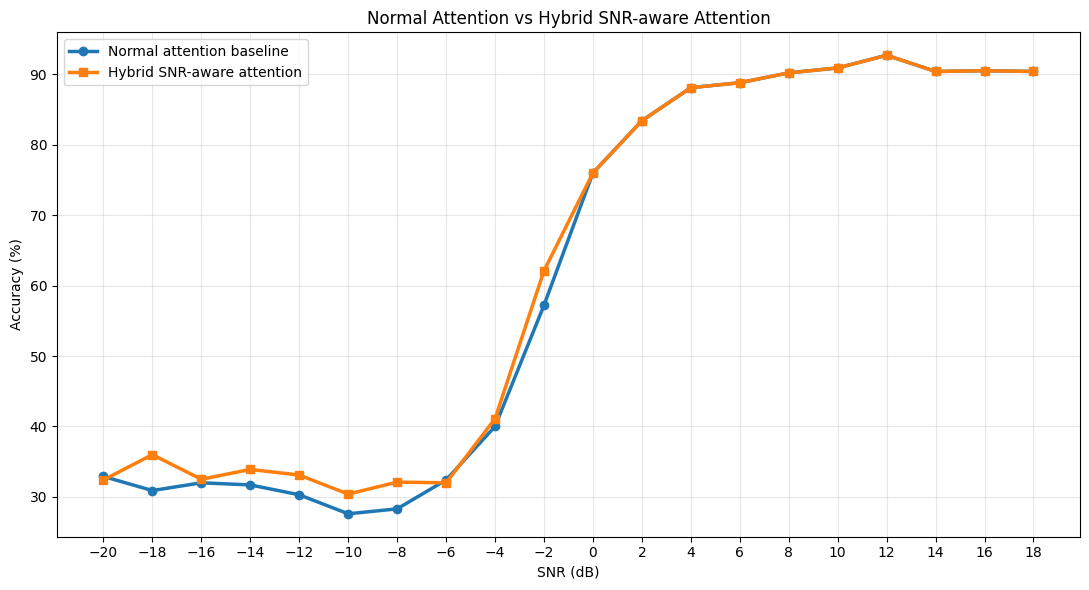

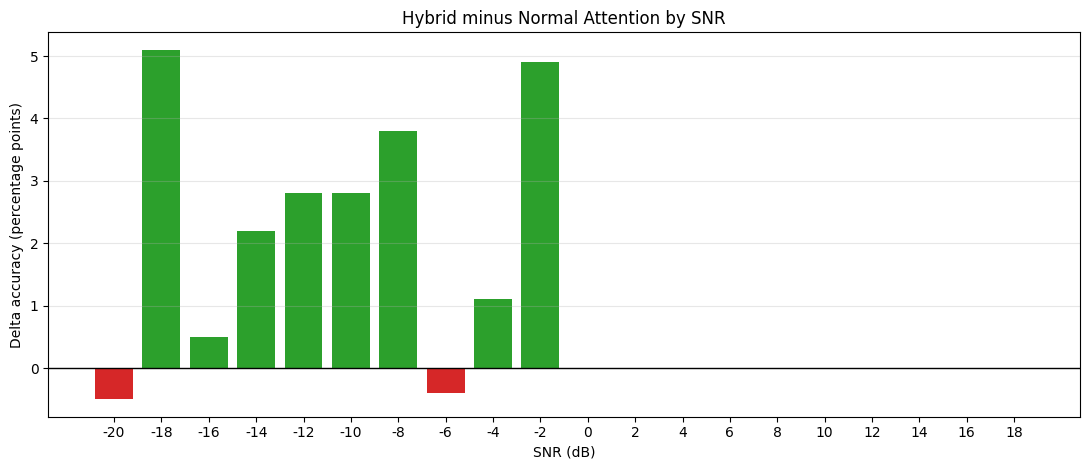

Saved: experiments/5class_hybrid_snr_aware_attention/results/comparison_with_normal_attention/normal_vs_hybrid_summary.csv
Saved: experiments/5class_hybrid_snr_aware_attention/results/comparison_with_normal_attention/normal_vs_hybrid_acc_per_snr.csv
Saved: experiments/5class_hybrid_snr_aware_attention/results/comparison_with_normal_attention/normal_vs_hybrid_acc_vs_snr.png
Saved: experiments/5class_hybrid_snr_aware_attention/results/comparison_with_normal_attention/hybrid_minus_normal_delta_by_snr.png
Normal attention overall confusion matrix (%):


,BPSK,QPSK,8PSK,QAM16,QAM64
BPSK,78.80,3.02,2.82,7.70,7.65
QPSK,3.38,55.90,8.22,18.77,13.73
8PSK,3.50,5.58,59.32,16.25,15.35
QAM16,3.45,3.80,7.20,63.00,22.55
QAM64,3.60,4.45,6.00,36.80,49.15


Hybrid SNR-aware attention overall confusion matrix (%):


,BPSK,QPSK,8PSK,QAM16,QAM64
BPSK,77.85,9.98,8.50,2.68,1.00
QPSK,2.85,70.75,19.55,5.15,1.70
8PSK,2.20,14.62,77.03,3.25,2.90
QAM16,2.85,17.52,19.68,51.08,8.87
QAM64,3.10,17.20,19.35,25.30,35.05


Hybrid minus Normal confusion matrix difference (percentage points):


,BPSK,QPSK,8PSK,QAM16,QAM64
BPSK,-0.95,6.95,5.68,-5.03,-6.65
QPSK,-0.53,14.85,11.32,-13.63,-12.02
8PSK,-1.30,9.05,17.70,-13.00,-12.45
QAM16,-0.60,13.72,12.48,-11.92,-13.68
QAM64,-0.50,12.75,13.35,-11.50,-14.10


/tmp/ipykernel_58/2257452385.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


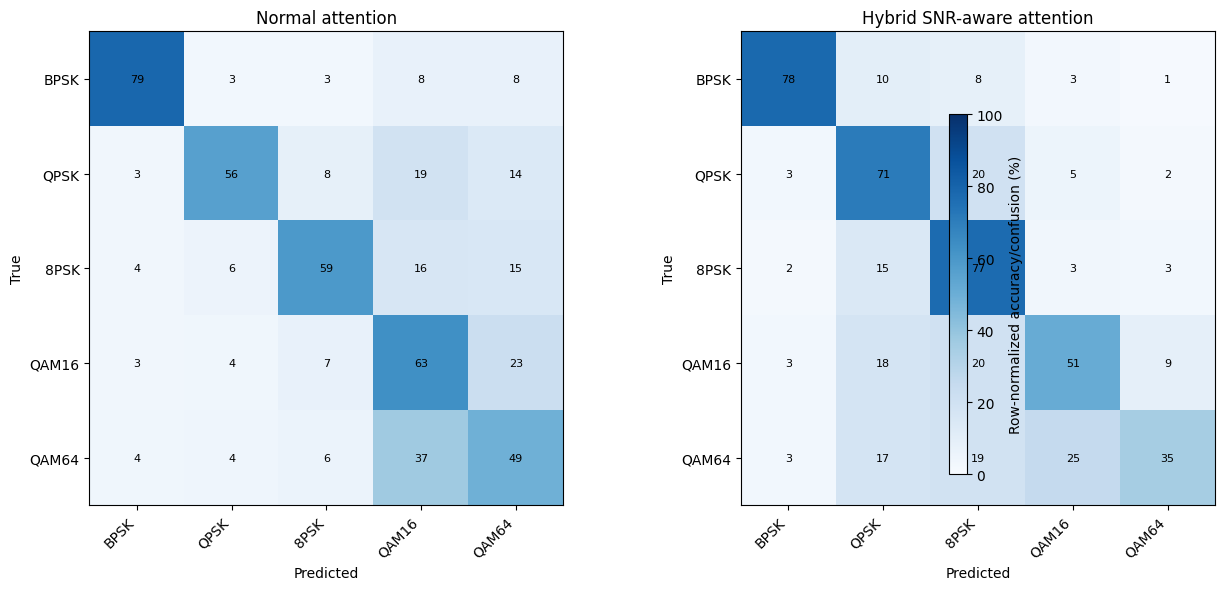

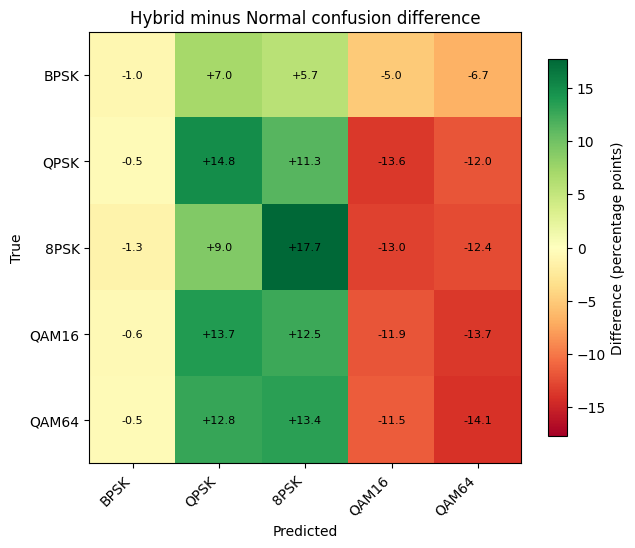

Saved: experiments/5class_hybrid_snr_aware_attention/results/comparison_with_normal_attention/confusion_normal_all_snrs.csv
Saved: experiments/5class_hybrid_snr_aware_attention/results/comparison_with_normal_attention/confusion_hybrid_all_snrs.csv
Saved: experiments/5class_hybrid_snr_aware_attention/results/comparison_with_normal_attention/confusion_hybrid_minus_normal_all_snrs.csv
Saved: experiments/5class_hybrid_snr_aware_attention/results/comparison_with_normal_attention/normal_vs_hybrid_confusion_all_snrs.png
Saved: experiments/5class_hybrid_snr_aware_attention/results/comparison_with_normal_attention/hybrid_minus_normal_confusion_delta_all_snrs.png


In [5]:
# CELL 5: Explicit Normal vs Hybrid comparison inside notebook
# This cell creates notebook-visible comparison tables and plots.

COMPARE_DIR = HYBRID_DIR / "results" / "comparison_with_normal_attention"
COMPARE_DIR.mkdir(parents=True, exist_ok=True)

score = pd.read_csv(HYBRID_DIR / "results" / "test_score.csv")
snr = pd.read_csv(HYBRID_DIR / "results" / "acc_per_snr.csv")

# Make the test summary easy to read.
test_summary = score.copy()
test_summary["accuracy_percent"] = 100.0 * test_summary["accuracy"]
if set(test_summary["model"]) >= {"normal_attention", "hybrid_snr_aware_attention"}:
    normal_acc = float(test_summary.loc[test_summary["model"] == "normal_attention", "accuracy"].iloc[0])
    hybrid_acc = float(test_summary.loc[test_summary["model"] == "hybrid_snr_aware_attention", "accuracy"].iloc[0])
    normal_loss = float(test_summary.loc[test_summary["model"] == "normal_attention", "loss"].iloc[0])
    hybrid_loss = float(test_summary.loc[test_summary["model"] == "hybrid_snr_aware_attention", "loss"].iloc[0])
else:
    raise ValueError("Expected normal_attention and hybrid_snr_aware_attention rows in test_score.csv")

headline = pd.DataFrame([
    {
        "comparison": "Hybrid - Normal",
        "normal_accuracy_percent": 100.0 * normal_acc,
        "hybrid_accuracy_percent": 100.0 * hybrid_acc,
        "delta_percent_points": 100.0 * (hybrid_acc - normal_acc),
        "normal_loss": normal_loss,
        "hybrid_loss": hybrid_loss,
    }
])

snr_compare = snr.copy()
snr_compare["normal_accuracy_percent"] = 100.0 * snr_compare["normal_attention_accuracy"]
snr_compare["hybrid_accuracy_percent"] = 100.0 * snr_compare["hybrid_accuracy"]
snr_compare["delta_percent_points"] = 100.0 * snr_compare["delta_hybrid_minus_normal"]

headline_csv = COMPARE_DIR / "normal_vs_hybrid_summary.csv"
snr_csv = COMPARE_DIR / "normal_vs_hybrid_acc_per_snr.csv"
headline.to_csv(headline_csv, index=False)
snr_compare.to_csv(snr_csv, index=False)

print("Normal vs Hybrid headline summary:")
display(headline)

print("Normal vs Hybrid by SNR:")
display(snr_compare[[
    "snr",
    "selected_model",
    "normal_accuracy_percent",
    "hybrid_accuracy_percent",
    "delta_percent_points",
]])

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(snr_compare["snr"], snr_compare["normal_accuracy_percent"],
        marker="o", linewidth=2.5, label="Normal attention baseline")
ax.plot(snr_compare["snr"], snr_compare["hybrid_accuracy_percent"],
        marker="s", linewidth=2.5, label="Hybrid SNR-aware attention")
ax.set_title("Normal Attention vs Hybrid SNR-aware Attention")
ax.set_xlabel("SNR (dB)")
ax.set_ylabel("Accuracy (%)")
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xticks(snr_compare["snr"])
plt.tight_layout()
curve_path = COMPARE_DIR / "normal_vs_hybrid_acc_vs_snr.png"
fig.savefig(curve_path, dpi=180, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(11, 4.8))
colors = ["#2ca02c" if x >= 0 else "#d62728" for x in snr_compare["delta_percent_points"]]
ax.bar(snr_compare["snr"].astype(str), snr_compare["delta_percent_points"], color=colors)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Hybrid minus Normal Attention by SNR")
ax.set_xlabel("SNR (dB)")
ax.set_ylabel("Delta accuracy (percentage points)")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
delta_path = COMPARE_DIR / "hybrid_minus_normal_delta_by_snr.png"
fig.savefig(delta_path, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved: {headline_csv}")
print(f"Saved: {snr_csv}")
print(f"Saved: {curve_path}")
print(f"Saved: {delta_path}")


# Overall confusion matrix comparison: normal vs hybrid
classes = ["BPSK", "QPSK", "8PSK", "QAM16", "QAM64"]
conf_normal_path = HYBRID_DIR / "results" / "confusion_normal_all_snrs.csv"
conf_hybrid_path = HYBRID_DIR / "results" / "confusion_hybrid_all_snrs.csv"

if conf_normal_path.exists() and conf_hybrid_path.exists():
    conf_normal = pd.read_csv(conf_normal_path, header=None).values
    conf_hybrid = pd.read_csv(conf_hybrid_path, header=None).values
else:
    raise FileNotFoundError(
        "Confusion CSVs missing. Re-run CELL 3 after updating the evaluator script."
    )

conf_delta = conf_hybrid - conf_normal
conf_normal_csv = COMPARE_DIR / "confusion_normal_all_snrs.csv"
conf_hybrid_csv = COMPARE_DIR / "confusion_hybrid_all_snrs.csv"
conf_delta_csv = COMPARE_DIR / "confusion_hybrid_minus_normal_all_snrs.csv"
pd.DataFrame(conf_normal, index=classes, columns=classes).to_csv(conf_normal_csv)
pd.DataFrame(conf_hybrid, index=classes, columns=classes).to_csv(conf_hybrid_csv)
pd.DataFrame(conf_delta, index=classes, columns=classes).to_csv(conf_delta_csv)

print("Normal attention overall confusion matrix (%):")
display(pd.DataFrame(np.round(conf_normal * 100, 2), index=classes, columns=classes))

print("Hybrid SNR-aware attention overall confusion matrix (%):")
display(pd.DataFrame(np.round(conf_hybrid * 100, 2), index=classes, columns=classes))

print("Hybrid minus Normal confusion matrix difference (percentage points):")
display(pd.DataFrame(np.round(conf_delta * 100, 2), index=classes, columns=classes))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, cm, title in [
    (axes[0], conf_normal, "Normal attention"),
    (axes[1], conf_hybrid, "Hybrid SNR-aware attention"),
]:
    im = ax.imshow(cm * 100, vmin=0, vmax=100, cmap="Blues")
    ax.set_title(title)
    ax.set_xticks(range(len(classes)))
    ax.set_yticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha="right")
    ax.set_yticklabels(classes)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i, f"{cm[i,j]*100:.0f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85, label="Row-normalized accuracy/confusion (%)")
plt.tight_layout()
conf_compare_path = COMPARE_DIR / "normal_vs_hybrid_confusion_all_snrs.png"
fig.savefig(conf_compare_path, dpi=180, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
lim = max(1e-6, abs(conf_delta * 100).max())
im = ax.imshow(conf_delta * 100, cmap="RdYlGn", vmin=-lim, vmax=lim)
ax.set_title("Hybrid minus Normal confusion difference")
ax.set_xticks(range(len(classes)))
ax.set_yticks(range(len(classes)))
ax.set_xticklabels(classes, rotation=45, ha="right")
ax.set_yticklabels(classes)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, f"{conf_delta[i,j]*100:+.1f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.85, label="Difference (percentage points)")
plt.tight_layout()
conf_delta_path = COMPARE_DIR / "hybrid_minus_normal_confusion_delta_all_snrs.png"
fig.savefig(conf_delta_path, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved: {conf_normal_csv}")
print(f"Saved: {conf_hybrid_csv}")
print(f"Saved: {conf_delta_csv}")
print(f"Saved: {conf_compare_path}")
print(f"Saved: {conf_delta_path}")


In [6]:
# CELL 6: Create repo-ready zip for ONLY hybrid results
stamp = datetime.now().strftime("%Y%m%d_%H%M")
zip_base = Path("/kaggle/working") / f"hybrid_snr_aware_attention_repo_ready_{stamp}"
zip_path = shutil.make_archive(
    str(zip_base),
    "zip",
    root_dir=str(WORK_DIR),
    base_dir="experiments/5class_hybrid_snr_aware_attention",
)

print(f"Created repo-ready zip: {zip_path}")
print("\nExtract this zip at the repo root. It will create/update:")
print("  experiments/5class_hybrid_snr_aware_attention/")
print("\nIncluded files:")
for path in sorted(HYBRID_DIR.rglob("*")):
    if path.is_file():
        print(" -", Path("experiments/5class_hybrid_snr_aware_attention") / path.relative_to(HYBRID_DIR))

display(FileLink(zip_path))


Created repo-ready zip: /kaggle/working/hybrid_snr_aware_attention_repo_ready_20260702_0743.zip

Extract this zip at the repo root. It will create/update:
  experiments/5class_hybrid_snr_aware_attention/

Included files:
 - experiments/5class_hybrid_snr_aware_attention/figures/acc_per_class_vs_snr.png
 - experiments/5class_hybrid_snr_aware_attention/figures/acc_vs_snr.png
 - experiments/5class_hybrid_snr_aware_attention/figures/confusion_all_snrs.png
 - experiments/5class_hybrid_snr_aware_attention/figures/confusion_normal_all_snrs.png
 - experiments/5class_hybrid_snr_aware_attention/figures/confusion_snr+00.png
 - experiments/5class_hybrid_snr_aware_attention/figures/confusion_snr+02.png
 - experiments/5class_hybrid_snr_aware_attention/figures/confusion_snr+04.png
 - experiments/5class_hybrid_snr_aware_attention/figures/confusion_snr+06.png
 - experiments/5class_hybrid_snr_aware_attention/figures/confusion_snr+08.png
 - experiments/5class_hybrid_snr_aware_attention/figures/confusion_s

/kaggle/working/hybrid_snr_aware_attention_repo_ready_20260702_0743.zip